In [1]:
#######################

# Heart Disease Project 

## Task 1 :
### - Data Wrangling (preprocessing and cleaning) 
 
## Task 2 :
### - How does the distribution of a numerical feature differ between the two classes of the target variable?
### - Show the distribution of target variable(Heart_stroke)

## Task 3 :
### - Apply  dimensionality reduction  and feature selection 

## Task 4 :
### - Apply Random Forest 

## Task 5 :
### - Apply Logistic Regression 

## Task 6 :
### - Apply Decision Tree 

## Task 7 :
### - Apply KNN

## Task 8 :
### - Apply SVM

## Task 9 :
### - Apply Neural Network



In [2]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sb
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import KNNImputer,SimpleImputer
import sklearn.metrics as metrics
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler , SMOTE, ADASYN
from sklearn.ensemble import RandomForestClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from category_encoders import OneHotEncoder
from sklearn.metrics  import confusion_matrix ,accuracy_score,f1_score,jaccard_score,log_loss ,classification_report,ConfusionMatrixDisplay
from category_encoders import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import plot_confusion_matrix, plot_roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
from sklearn import preprocessing, feature_selection, decomposition, linear_model, tree, neighbors, svm, neural_network, metrics
from sklearn.preprocessing import OrdinalEncoder , OneHotEncoder ,MinMaxScaler
from sklearn.feature_selection import RFE , SequentialFeatureSelector ,mutual_info_classif,chi2
from imblearn.over_sampling import SMOTE


In [3]:
def wrangle(path):
    df = pd.read_csv(path,encoding='latin-1')
    
    # convert ordinal data into numerical 
    encoder = OrdinalEncoder()
    selected_coloums = ["Gender" , "education" , "prevalentStroke" , "Heart_ stroke"]
    df[selected_coloums] = encoder.fit_transform(df[selected_coloums])
    # apply normalization to numerical features
    scaler = preprocessing.MinMaxScaler()
    num_cols = ["age", "glucose", "BMI",'totChol','sysBP','diaBP','heartRate','cigsPerDay','education']
    df[num_cols] = scaler.fit_transform(df[num_cols])
    # using KNN algorithm fill missing values
    imputer = KNNImputer()
    df_impute = imputer.fit_transform(df)
    df = pd.DataFrame(df_impute, columns=df.columns)
    ## drop multicollinearlity features and the less importans feature
    df = df.drop(columns = ['currentSmoker','prevalentHyp','diaBP','diabetes','heartRate'])
     
    return df

In [4]:
path = 'D:\Data Tools\Data Tools Final Project\Heart Diseas\heart_disease.csv'

In [5]:
df = wrangle(path)

In [6]:
df.head()

,Gender,age,education,cigsPerDay,BPMeds,prevalentStroke,totChol,sysBP,BMI,glucose,Heart_ stroke
0,1.0,0.184211,0.333333,0.000000,0.0,0.0,0.149406,0.106383,0.277024,0.104520,0.0
1,0.0,0.368421,0.666667,0.000000,0.0,0.0,0.242784,0.177305,0.319680,0.101695,0.0
2,1.0,0.421053,1.000000,0.285714,0.0,0.0,0.234295,0.208038,0.237518,0.084746,0.0
3,0.0,0.763158,0.000000,0.428571,0.0,0.0,0.200340,0.314421,0.316045,0.177966,1.0
4,0.0,0.368421,0.000000,0.328571,0.0,0.0,0.302207,0.219858,0.183228,0.127119,0.0


In [7]:
df.tail()

,Gender,age,education,cigsPerDay,BPMeds,prevalentStroke,totChol,sysBP,BMI,glucose,Heart_ stroke
4233,1.0,0.473684,1.000000,0.014286,0.0,0.0,0.349745,0.451537,0.252787,0.129944,1.0
4234,1.0,0.500000,0.000000,0.614286,0.0,0.0,0.169779,0.203310,0.101066,0.079096,0.0
4235,0.0,0.421053,0.666667,0.285714,0.0,0.0,0.239389,0.224586,0.156568,0.129944,0.0
4236,0.0,0.315789,1.000000,0.214286,0.0,0.0,0.174873,0.203310,0.087736,0.109605,0.0
4237,0.0,0.526316,0.666667,0.000000,0.0,0.0,0.275042,0.236407,0.143723,0.189266,0.0


In [8]:
df.shape

(4238, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           4238 non-null   float64
 1   age              4238 non-null   float64
 2   education        4238 non-null   float64
 3   cigsPerDay       4238 non-null   float64
 4   BPMeds           4238 non-null   float64
 5   prevalentStroke  4238 non-null   float64
 6   totChol          4238 non-null   float64
 7   sysBP            4238 non-null   float64
 8   BMI              4238 non-null   float64
 9   glucose          4238 non-null   float64
 10  Heart_ stroke    4238 non-null   float64
dtypes: float64(11)
memory usage: 364.3 KB


In [10]:
df.describe()

,Gender,age,education,cigsPerDay,BPMeds,prevalentStroke,totChol,sysBP,BMI,glucose,Heart_ stroke
count,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000
mean,0.429212,0.462762,0.656583,0.129551,0.029778,0.005899,0.220337,0.230981,0.248766,0.118094,0.151958
std,0.495022,0.225583,0.360790,0.170268,0.168881,0.076587,0.075413,0.104199,0.098760,0.065057,0.359023
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.263158,0.333333,0.000000,0.000000,0.000000,0.168081,0.158392,0.182744,0.090395,0.000000
50%,0.000000,0.447368,0.666667,0.000000,0.000000,0.000000,0.215620,0.210402,0.238972,0.107345,0.000000
75%,1.000000,0.631579,1.000000,0.285714,0.000000,0.000000,0.264856,0.286052,0.302957,0.129944,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
#####################################

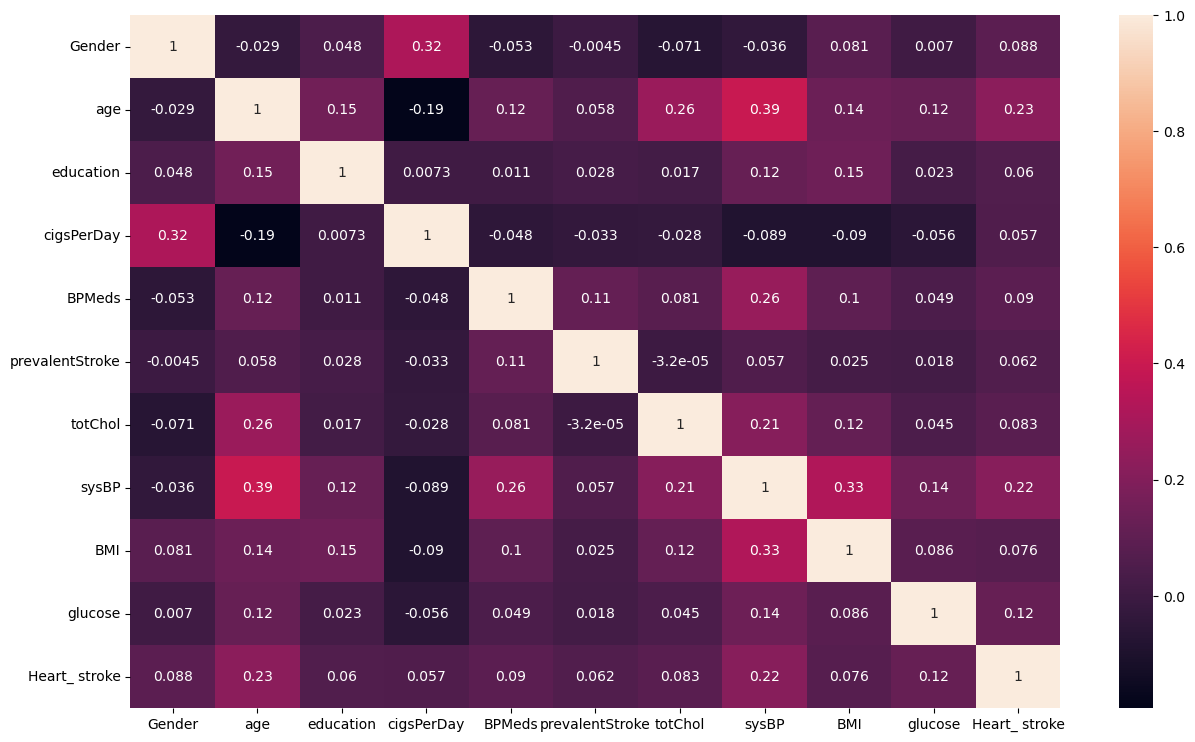

In [12]:
plt.figure(figsize = (15,9))
correlation = df.corr()
sb.heatmap(correlation,annot = True);

In [13]:
target = "Heart_ stroke"
X = df.drop(columns=target)
y = df[target]

print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (4238, 10)
y shape: (4238,)


In [14]:
chi_scores =chi2(X , y)

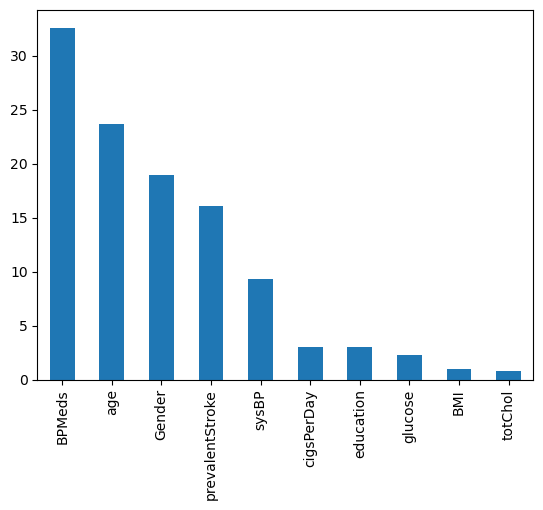

In [15]:
# higher the chi value, higher the importance
chi_values = pd.Series(chi_scores[0], index=X.columns)
chi_values.sort_values(ascending=False, inplace=True)
chi_values.plot.bar();

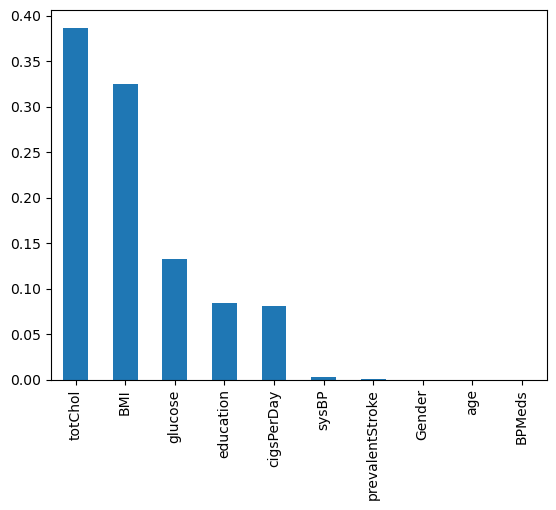

In [16]:
# if p-value > 0.5, lower the importance
p_values = pd.Series(chi_scores[1], index=X.columns)
p_values.sort_values(ascending=False, inplace=True)
p_values.plot.bar();

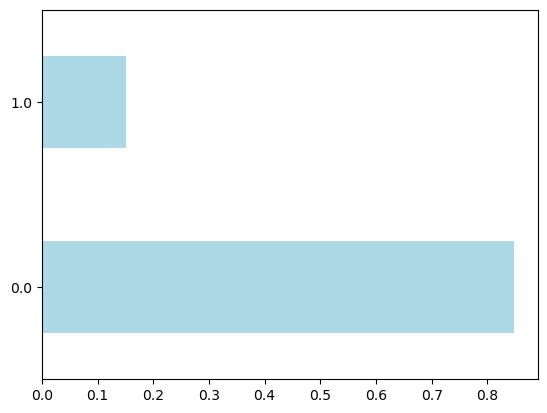

In [17]:
df["Heart_ stroke"].value_counts(normalize=True).plot(kind = "barh" , color = "lightblue");

In [18]:
########################################################

# Splitting Data with and without oversampling 
## Oversampling Techniques:

### - Random Oversampling: This technique randomly duplicates minority class samples to increase their     representation in the dataset.
### - SMOTE (Synthetic Minority Over-sampling Technique): SMOTE creates synthetic samples for the minority class by interpolating between neighboring samples.
### - ADASYN (Adaptive Synthetic Sampling): ADASYN generates synthetic samples for the minority class based on the density distribution of the data. 

## Note : Try to run one oversampling technique not all techniques.

#  Without Oversampling

In [19]:
X_train, X_test, y_train, y_test =train_test_split(X , y , test_size=0.2 , random_state=42)

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

X_train shape: (3390, 10)
y_train shape: (3390,)
X_test shape: (848, 10)
y_test shape: (848,)


# Oversampling : ADASYN (Adaptive Synthetic Sampling)

In [20]:
adasyn = ADASYN(random_state = 42)

In [21]:
X_os, y_os = adasyn.fit_resample(X , y)

In [96]:
X_train_os, X_test_os, y_train_os, y_test_os = train_test_split(X_os , y_os , test_size=0.2 , random_state=42)

print("X_train_os shape:",X_train_os.shape)
print("y_train_os shape:",y_train_os.shape)
print("X_test_os shape:",X_test_os.shape)
print("y_test_os shape:",y_test_os.shape)

X_train_os shape: (5750, 10)
y_train_os shape: (5750,)
X_test_os shape: (1438, 10)
y_test_os shape: (1438,)


# Oversampling :  SMOTE (Synthetic Minority Over-sampling Technique)

In [97]:
# Perform oversampling using SMOTE
S_oversampler = SMOTE(random_state=42)
X_os, y_os= S_oversampler.fit_resample(X, y)

In [98]:
# Split the oversampled data into training and testing sets
X_train_os, X_test_os, y_train_os, y_test_os = train_test_split(X_os , y_os ,test_size=0.2 , random_state=42)

print("X_train_os shape:",X_train_os.shape)
print("y_train_os shape:",y_train_os.shape)
print("X_test_os shape:",X_test_os.shape)
print("y_test_os shape:",y_test_os.shape)

X_train_os shape: (5750, 10)
y_train_os shape: (5750,)
X_test_os shape: (1438, 10)
y_test_os shape: (1438,)


# Oversampling : Random Oversampling

In [99]:
R_over_sample = RandomOverSampler(random_state=42)
X_os, y_os = R_over_sample.fit_resample(X , y)

In [100]:
X_train_os, X_test_os, y_train_os, y_test_os = train_test_split(X_os , y_os , test_size=0.2 , random_state=42)

print("X_train_os shape:",X_train_os.shape)
print("y_train_os shape:",y_train_os.shape)
print("X_test_os shape:",X_test_os.shape)
print("y_test_os shape:",y_test_os.shape)

X_train_os shape: (5750, 10)
y_train_os shape: (5750,)
X_test_os shape: (1438, 10)
y_test_os shape: (1438,)


In [27]:
###########################

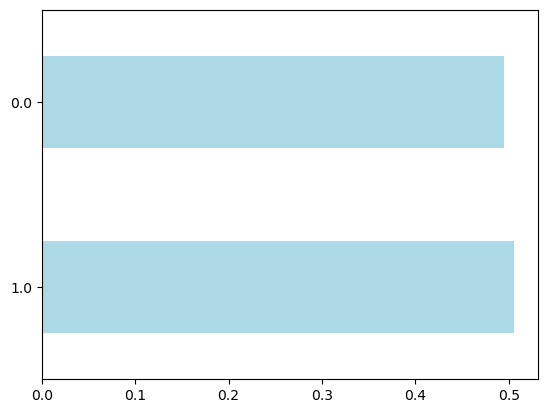

In [28]:
y_train_os.value_counts(normalize=True).plot(kind = "barh" , color = "lightblue");

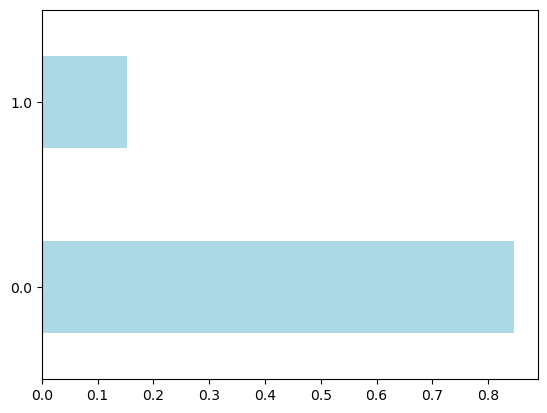

In [29]:
y_train.value_counts(normalize=True).plot(kind = "barh" , color = "lightblue");

In [30]:
####################################

# Logistic Regression Model

In [31]:
L_R_model = LogisticRegression(max_iter = 1500)
# Fit model to training data
L_R_model.fit(X_train,y_train)

LogisticRegression(max_iter=1500)

In [32]:
acc_train = accuracy_score(y_train,L_R_model.predict(X_train))
acc_test = L_R_model.score(X_test,y_test)

print("Training Accuracy:",  acc_train)
print("Test Accuracy:", acc_test)

Training Accuracy: 0.8536873156342183
Test Accuracy: 0.8549528301886793


In [33]:
print(classification_report(y_test,L_R_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92       724
         1.0       0.54      0.06      0.10       124

    accuracy                           0.85       848
   macro avg       0.70      0.52      0.51       848
weighted avg       0.81      0.85      0.80       848



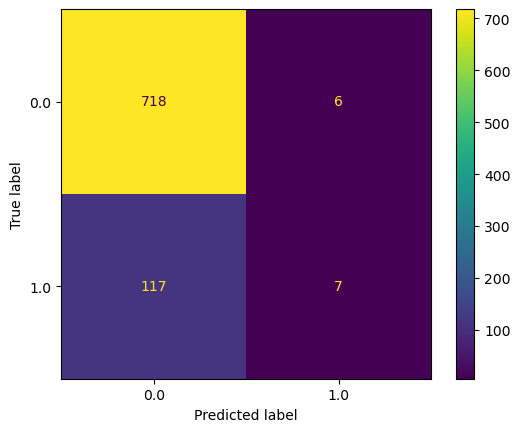

In [34]:
ConfusionMatrixDisplay.from_estimator(L_R_model,X_test ,y_test);

#  DecisionTree

In [35]:
X_train_os, X_val_os, y_train_os, y_val_os =  train_test_split(
         X_train_os, y_train_os, test_size = 0.2, random_state = 42)

In [36]:
depth_hyperparams = range(1,50,2)

In [37]:
training_acc = []
validation_acc = []

for d in depth_hyperparams:
    test_model = make_pipeline(
                DecisionTreeClassifier(random_state = 42,max_depth = d)
           )
    
    test_model.fit(X_train_os, y_train_os)
    training_acc.append(test_model.score(X_train_os,y_train_os))
    validation_acc.append(test_model.score(X_val_os,y_val_os))

print("Training Accuracy Scores:",  training_acc[:3])
print("Validation Accuracy Scores:", validation_acc[:3])

Training Accuracy Scores: [0.6393478260869565, 0.643695652173913, 0.7010869565217391]
Validation Accuracy Scores: [0.6226086956521739, 0.6278260869565218, 0.6747826086956522]


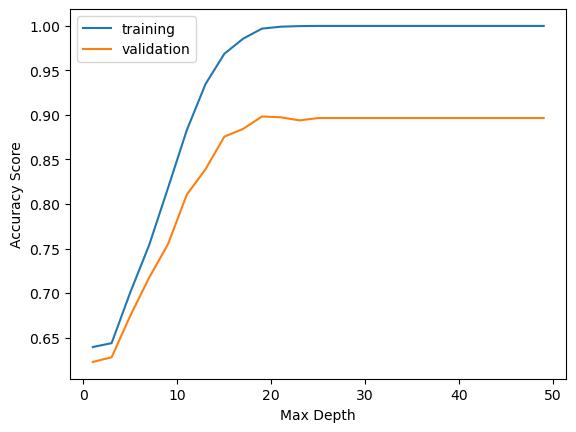

In [38]:
# Plot `depth_hyperparams`, `training_acc`
plt.plot(depth_hyperparams, training_acc, label = 'training')
plt.plot(depth_hyperparams, validation_acc, label = 'validation')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy Score')
plt.legend();

In [39]:
D_T_model = DecisionTreeClassifier(random_state = 42, max_depth = 20)
D_T_model.fit(X_train_os,y_train_os)

DecisionTreeClassifier(max_depth=20, random_state=42)

In [40]:
acc_train = accuracy_score(y_train_os,D_T_model.predict(X_train_os))
acc_val = D_T_model.score(X_val_os,y_val_os)

print("Training Accuracy:", round(acc_train, 2))
print("Validation Accuracy:", round(acc_val, 2))
 

Training Accuracy: 1.0
Validation Accuracy: 0.89


In [41]:
print(classification_report(y_test_os,D_T_model.predict(X_test_os)))

              precision    recall  f1-score   support

         0.0       0.99      0.81      0.89       752
         1.0       0.83      0.99      0.90       686

    accuracy                           0.90      1438
   macro avg       0.91      0.90      0.90      1438
weighted avg       0.91      0.90      0.90      1438



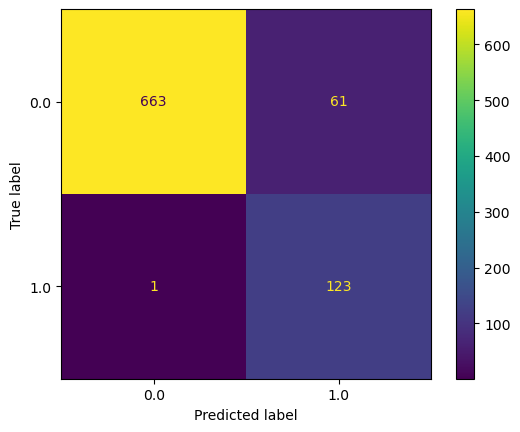

In [42]:
ConfusionMatrixDisplay.from_estimator(D_T_model,X_test ,y_test);


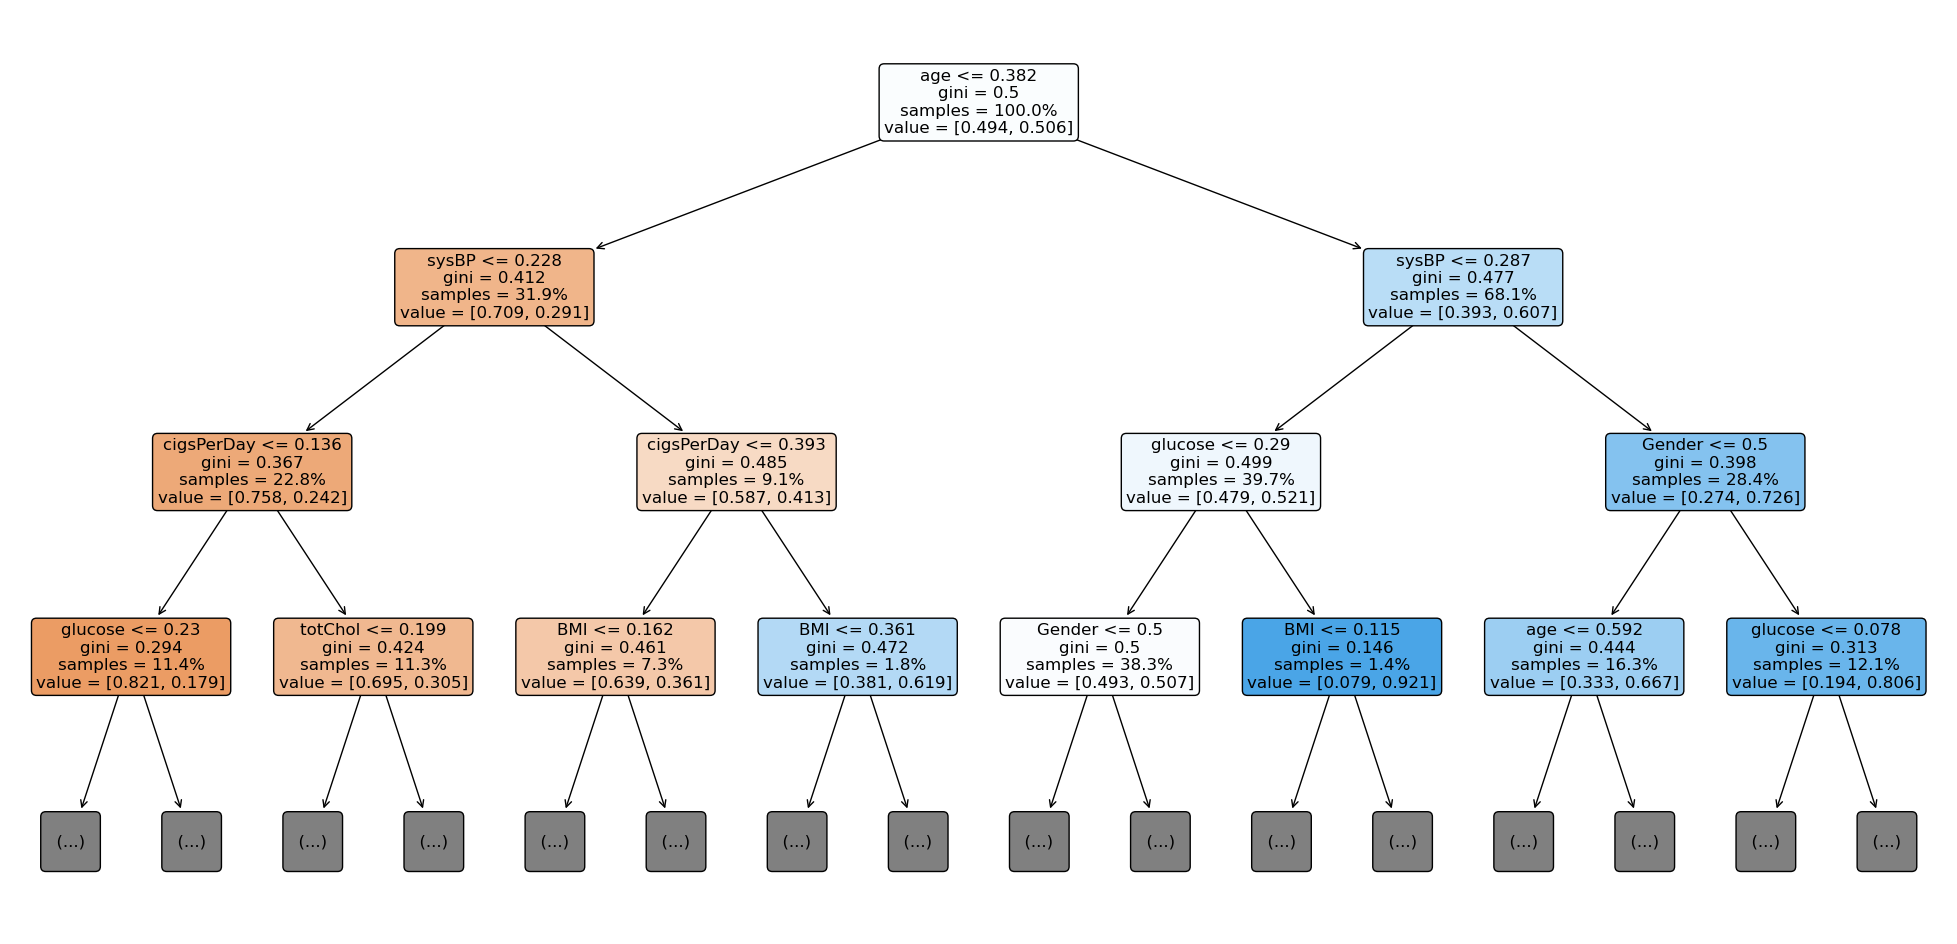

In [43]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

fig, ax = plt.subplots(figsize=(25, 12))
plot_tree(
    decision_tree = D_T_model,
    feature_names = X_train.columns ,
    filled=True,  
    rounded=True,   
    proportion=True,   
    max_depth=3,   
    fontsize=12,  
    ax=ax,  
);

# Random Forest model

In [44]:
R_F_model = RandomForestClassifier(random_state=42)
R_F_model.fit(X_train_os , y_train_os)

RandomForestClassifier(random_state=42)

In [45]:
traning_score = R_F_model.score(X_train_os,y_train_os)
test_score = R_F_model.score(X_test_os,y_test_os)

print("traning_score : " ,traning_score)
print("test_score : " ,test_score)

traning_score :  1.0
test_score :  0.9520166898470097


In [46]:
print(classification_report(y_test_os,R_F_model.predict(X_test_os)))

              precision    recall  f1-score   support

         0.0       0.99      0.92      0.95       752
         1.0       0.92      0.99      0.95       686

    accuracy                           0.95      1438
   macro avg       0.95      0.95      0.95      1438
weighted avg       0.95      0.95      0.95      1438



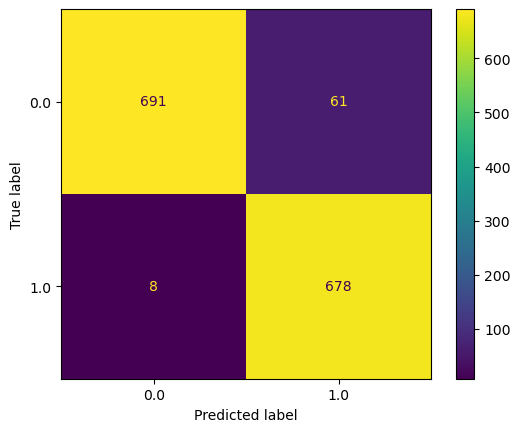

In [47]:
ConfusionMatrixDisplay.from_estimator(R_F_model,X_test_os ,y_test_os);

In [48]:
# Get feature names
names = X_train_os.columns
# get importance
importans = R_F_model.feature_importances_
# make series
series = pd.Series(data=importans , index=names).sort_values()

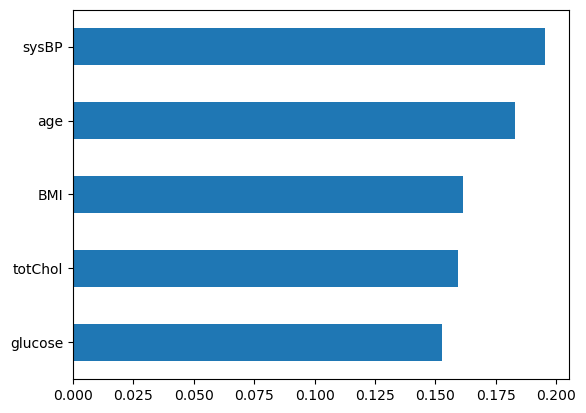

In [49]:
# bar plot for the most important feature 
series.tail(5).plot(kind="barh");

# SVM Model

In [50]:
# Train the SVM model
SVM_model = SVC(kernel='poly', degree=4)  # You can try different degrees
SVM_model.fit(X_train, y_train)

SVC(degree=4, kernel='poly')

In [51]:
y_pred = SVM_model.predict(X_test)

In [52]:
traning_score = SVM_model.score(X_train,y_train)
test_score = SVM_model.score(X_test,y_test)

print("traning_score : " ,traning_score)
print("test_score : " ,test_score)

traning_score :  0.8572271386430679
test_score :  0.8549528301886793


In [53]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:\n', report)

Accuracy: 0.85
Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.99      0.92       724
         1.0       0.56      0.04      0.08       124

    accuracy                           0.85       848
   macro avg       0.71      0.52      0.50       848
weighted avg       0.81      0.85      0.80       848



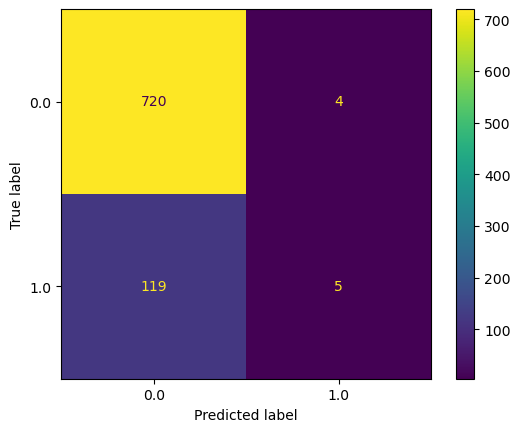

In [54]:
ConfusionMatrixDisplay.from_estimator(SVM_model,X_test ,y_test);

In [55]:
svm_model = SVC()

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 0.01, 0.001]
}

# Perform grid search cross-validation
grid_search = GridSearchCV(svm_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_

# Create an optimized SVM model
svm_optimized = SVC(**best_params)

# Train the optimized SVM model
svm_optimized.fit(X_train, y_train)

# Evaluate the model
accuracy = svm_optimized.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8537735849056604


# KNN Model

In [56]:
KNN_model = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': [3, 5, 7,9,12],  # Try different values for the number of neighbors
    'weights': ['uniform', 'distance'],  # Try different weighting schemes
}

In [57]:
# Perform grid search cross-validation
grid_search_knn = GridSearchCV(KNN_model, param_grid_knn, cv=5)
grid_search_knn.fit(X_train, y_train)

# Get the best hyperparameters
best_params_knn = grid_search_knn.best_params_

In [58]:
knn_optimized = KNeighborsClassifier(**best_params_knn)

In [59]:
knn_optimized.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=12)

In [60]:
traning_score = knn_optimized.score(X_train,y_train)
test_score = knn_optimized.score(X_test,y_test)

print("traning_score : " ,traning_score)
print("test_score : " ,test_score)

traning_score :  0.8492625368731563
test_score :  0.8525943396226415


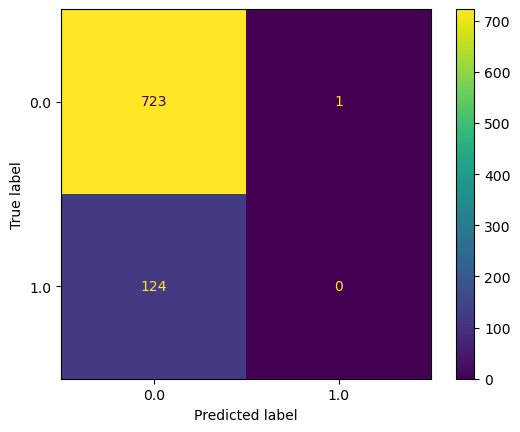

In [61]:
ConfusionMatrixDisplay.from_estimator(knn_optimized,X_test ,y_test);

# Neural Network Model
## - MLP (Multi-Layer Perceptron)
## - Sequential Model

In [73]:
# Create a neural network classifier
nn = MLPClassifier()

# Train the neural network classifier
nn.fit(X_train, y_train)

MLPClassifier()

In [74]:
# Evaluate the neural network classifier
nn_accuracy = nn.score(X_test, y_test)
print("Neural Network Accuracy:", nn_accuracy)

Neural Network Accuracy: 0.8573113207547169


In [83]:
nn = MLPClassifier()

# Define the parameter grid for hyperparameter tuning
param_grid_nn = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],  # Try different hidden layer sizes
    'activation': ['relu', 'tanh','sigmoid'],  # Try different activation functions
}

# Perform grid search cross-validation
grid_search_nn = GridSearchCV(nn, param_grid_nn, cv=5)
grid_search_nn.fit(X_train, y_train)

# Get the best hyperparameters
best_params_nn = grid_search_nn.best_params_

# Create a new neural network classifier with the best hyperparameters
nn_optimized = MLPClassifier(**best_params_nn)

# Train the optimized neural network classifier
nn_optimized.fit(X_train, y_train)

MLPClassifier()

In [84]:
nn_optimized.score(X_train,y_train)
nn_optimized.score(X_test,y_test)


0.8584905660377359

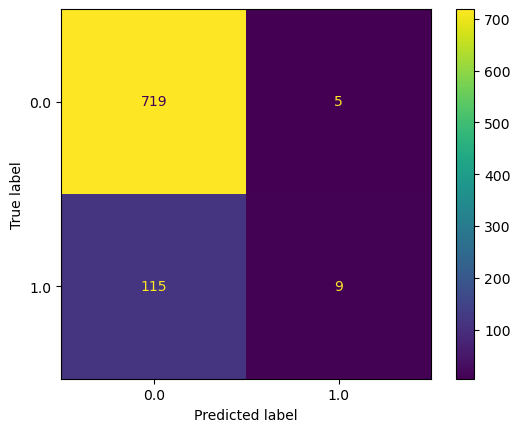

In [85]:
ConfusionMatrixDisplay.from_estimator(nn_optimized,X_test ,y_test);

In [78]:
#################################################################

In [79]:
# Create the model architecture
nn_model = Sequential()
nn_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
nn_model.add(Dense(32, activation='relu'))
nn_model.add(Dense(1, activation='sigmoid'))

# Compile the model
nn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
nn_model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
106/106 [==============================] - 1s 2ms/step - loss: 0.5054 - accuracy: 0.8277
Epoch 2/100
106/106 [==============================] - 0s 1ms/step - loss: 0.4357 - accuracy: 0.8466
Epoch 3/100
106/106 [==============================] - 0s 1ms/step - loss: 0.4159 - accuracy: 0.8466
Epoch 4/100
106/106 [==============================] - 0s 1ms/step - loss: 0.4009 - accuracy: 0.8466
Epoch 5/100
106/106 [==============================] - 0s 1ms/step - loss: 0.3913 - accuracy: 0.8472
Epoch 6/100
106/106 [==============================] - 0s 1ms/step - loss: 0.3895 - accuracy: 0.8478
Epoch 7/100
106/106 [==============================] - 0s 1ms/step - loss: 0.3859 - accuracy: 0.8525
Epoch 8/100
106/106 [==============================] - 0s 1ms/step - loss: 0.3847 - accuracy: 0.8534
Epoch 9/100
106/106 [==============================] - 0s 1ms/step - loss: 0.3849 - accuracy: 0.8543
Epoch 10/100
106/106 [==============================] - 0s 1ms/step - loss: 0.3829 - accura

In [95]:
# Make predictions and evaluate
y_pred = nn_model.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred > 0.7)
print("Accuracy of Neural Network:", accuracy)

27/27 [==============================] - 0s 872us/step
Accuracy of Neural Network: 0.8596698113207547
